# IBM Stock EDA

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
sys.path.append(os.path.abspath('..'))
from src.utils import count_outliers_iqr

sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)

## Load the data

In [26]:
df = pd.read_csv("../data/raw/ibm_stock_1980_2025.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Adj Factor
0,1980-01-02,15.057361,15.415870,14.937859,14.937859,0.965845,"1,723,808",0.0,0.0,0.064657
1,1980-01-03,14.937859,15.176864,14.639101,15.176864,0.981298,"2,553,495",0.0,0.0,0.064657
2,1980-01-04,15.176864,15.236616,15.057361,15.146989,0.979366,"1,978,195",0.0,0.0,0.064657
3,1980-01-07,15.146989,15.146989,14.967734,15.087237,0.975503,"1,480,718",0.0,0.0,0.064657
4,1980-01-08,15.087237,16.132887,14.967734,16.103010,1.041180,"2,968,130",0.0,0.0,0.064657


In [3]:
df.shape

(11488, 10)

## Basic info and data checks

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11488 entries, 0 to 11487
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          11488 non-null  str    
 1   Open          11488 non-null  float64
 2   High          11488 non-null  float64
 3   Low           11488 non-null  float64
 4   Close         11488 non-null  float64
 5   Adj Close     11488 non-null  float64
 6   Volume        11488 non-null  str    
 7   Dividends     11488 non-null  float64
 8   Stock Splits  11488 non-null  float64
 9   Adj Factor    11488 non-null  float64
dtypes: float64(8), str(2)
memory usage: 1.1 MB


In [5]:
df.dtypes

Date                str
Open            float64
High            float64
Low             float64
Close           float64
Adj Close       float64
Volume              str
Dividends       float64
Stock Splits    float64
Adj Factor      float64
dtype: object

In [6]:
df.describe()

,Open,High,Low,Close,Adj Close,Dividends,Stock Splits,Adj Factor
count,11488.000000,11488.000000,11488.000000,11488.000000,11488.000000,11488.000000,11488.000000,11488.000000
mean,86.395437,87.205402,85.627898,86.434003,50.850399,0.009136,0.000440,0.411739
std,59.715942,60.191946,59.273661,59.765258,52.400382,0.100572,0.028146,0.284595
min,9.799235,9.978489,9.709608,9.799235,0.800124,0.000000,0.000000,0.064657
25%,27.605164,27.844168,27.336281,27.605164,2.569202,0.000000,0.000000,0.104355
50%,84.574570,85.468452,83.742832,84.694077,42.765790,0.000000,0.000000,0.504918
75%,132.660133,133.749996,131.791824,132.796360,93.500592,0.000000,0.000000,0.597871
max,294.549988,296.160004,290.359985,294.779999,294.779999,1.680000,2.000000,1.000000


In [8]:
# how many duplicate rows
df.duplicated().sum()

np.int64(0)

## Fix date column

In [37]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df["Date"].min(), df["Date"].max()

(Timestamp('1980-01-02 00:00:00'), Timestamp('2025-07-30 00:00:00'))

## Missing values

In [38]:
df.isnull().sum()

Date            0
Open            0
High            0
Low             0
Close           0
Adj Close       0
Volume          0
Dividends       0
Stock Splits    0
Adj Factor      0
dtype: int64

## Date continuity check
See if there are gaps in the trading days (weekends and holidays are expected, but big gaps are worth checking).

In [39]:
df["days_gap"] = df["Date"].diff().dt.days
df["days_gap"].value_counts().sort_index(ascending=False).head(10)

days_gap
7.0       1
5.0       2
4.0     287
3.0    2088
2.0     108
1.0    9001
Name: count, dtype: int64

In [46]:
# rows where the gap between trading days is unusually big
df[df["days_gap"] == 7]

,Date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Adj Factor,days_gap
5482,2001-09-17,89.770554,91.644356,88.479927,89.235184,44.762874,"15,828,909",0.0,0.0,0.501628,7.0


## Price trends over time

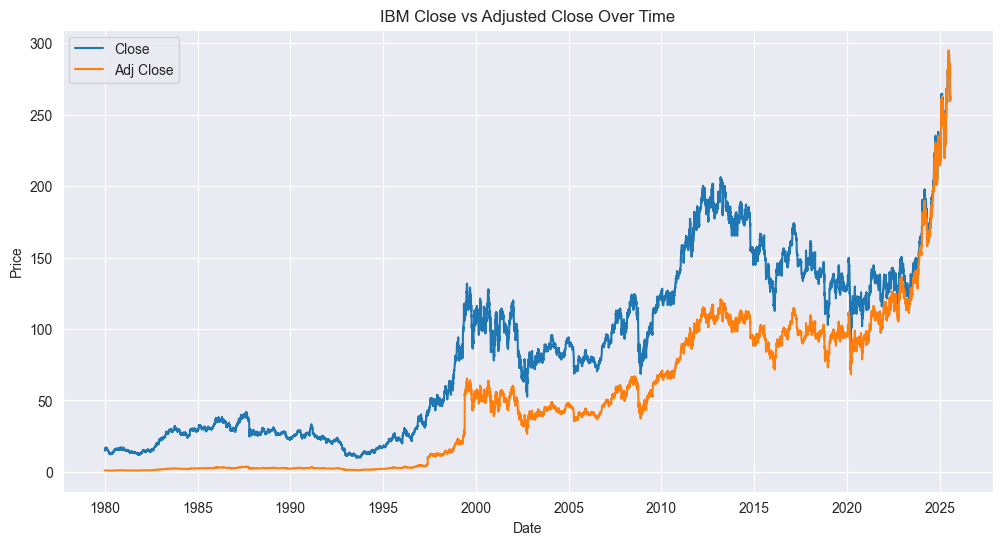

In [47]:
plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["Adj Close"], label="Adj Close")
plt.legend()
plt.title("IBM Close vs Adjusted Close Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

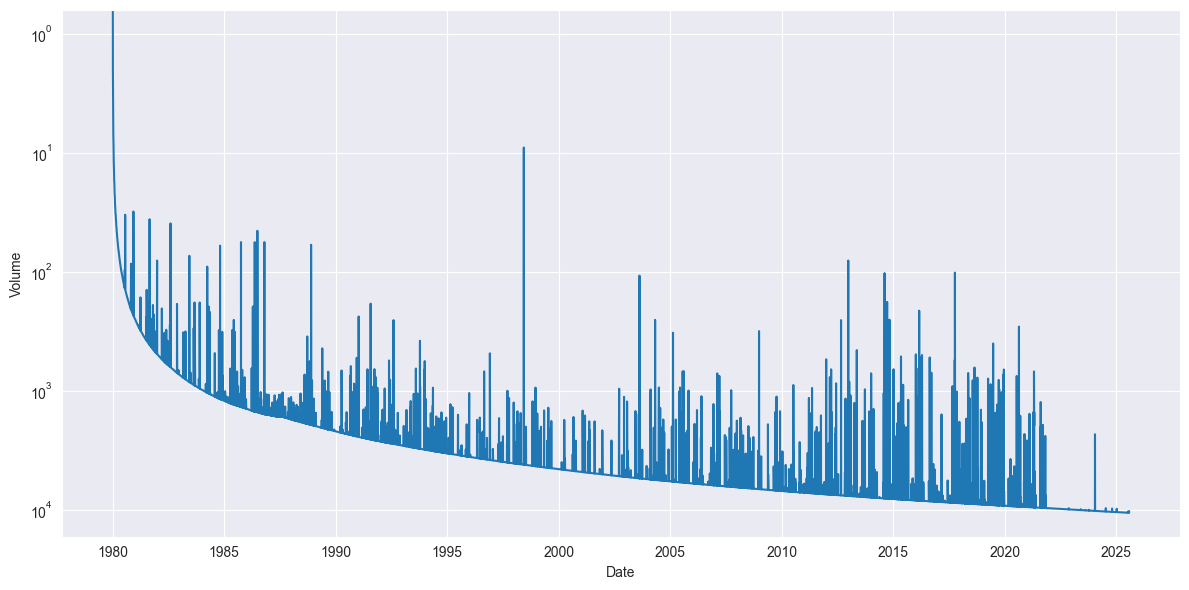

In [ ]:
sns.lineplot(data=df, x='Date', y='Volume')

plt.yscale('log')
plt.tight_layout()
plt.show()

## Dividends and stock splits

In [56]:
df[df["Dividends"] > 0].shape[0]

182

In [57]:
df[df["Stock Splits"] > 0]

,Date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Adj Factor,days_gap
4400,1997-05-28,43.260036,43.917305,42.304016,43.080784,5.275114,"18,722,145",0.0,2.00,0.122447,1.0
4904,1999-05-27,111.555923,111.735184,107.672081,110.898659,27.524728,"11,037,915",0.0,2.00,0.248197,1.0
10552,2021-11-04,123.050003,123.339996,119.900002,120.849998,98.262825,"7,208,700",0.0,1.05,0.813097,1.0


## Correlation

In [66]:
df['Volume'] = df['Volume'].apply(lambda x: float(x.replace(',','')))

In [ ]:
num_cols = ["Open", "High", "Low", "Close", "Volume", "Dividends", "Stock Splits", "Adj Close", "Adj Factor"]

corr = df[num_cols].corr()
corr

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Adj Close,Adj Factor
Open,1.000000,0.999885,0.999883,0.999781,-0.213154,0.063670,0.000131,0.950060,0.897434
High,0.999885,1.000000,0.999826,0.999893,-0.209635,0.063252,0.000022,0.950234,0.897995
Low,0.999883,0.999826,1.000000,0.999884,-0.217050,0.063333,-0.000343,0.949979,0.896823
Close,0.999781,0.999893,0.999884,1.000000,-0.213254,0.063044,-0.000085,0.950340,0.897380
Volume,-0.213154,-0.209635,-0.217050,-0.213254,1.000000,-0.024571,0.023233,-0.236682,-0.175373
Dividends,0.063670,0.063252,0.063333,0.063044,-0.024571,1.000000,-0.001419,0.070459,0.069809
Stock Splits,0.000131,0.000022,-0.000343,-0.000085,0.023233,-0.001419,1.000000,-0.005195,-0.005263
Adj Close,0.950060,0.950234,0.949979,0.950340,-0.236682,0.070459,-0.005195,1.000000,0.923177
Adj Factor,0.897434,0.897995,0.896823,0.897380,-0.175373,0.069809,-0.005263,0.923177,1.000000


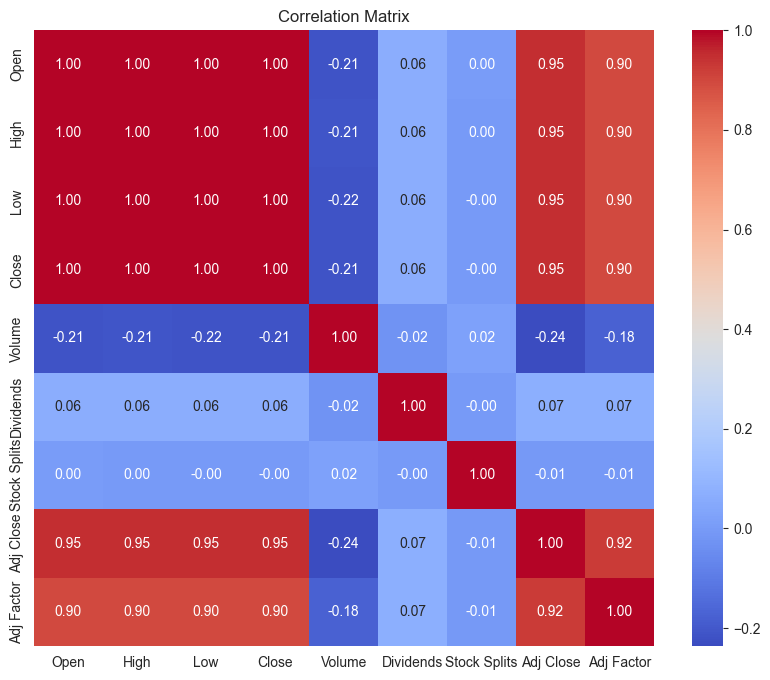

In [70]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## Outliers
Using boxplots and IQR to check for outliers in price and volume.

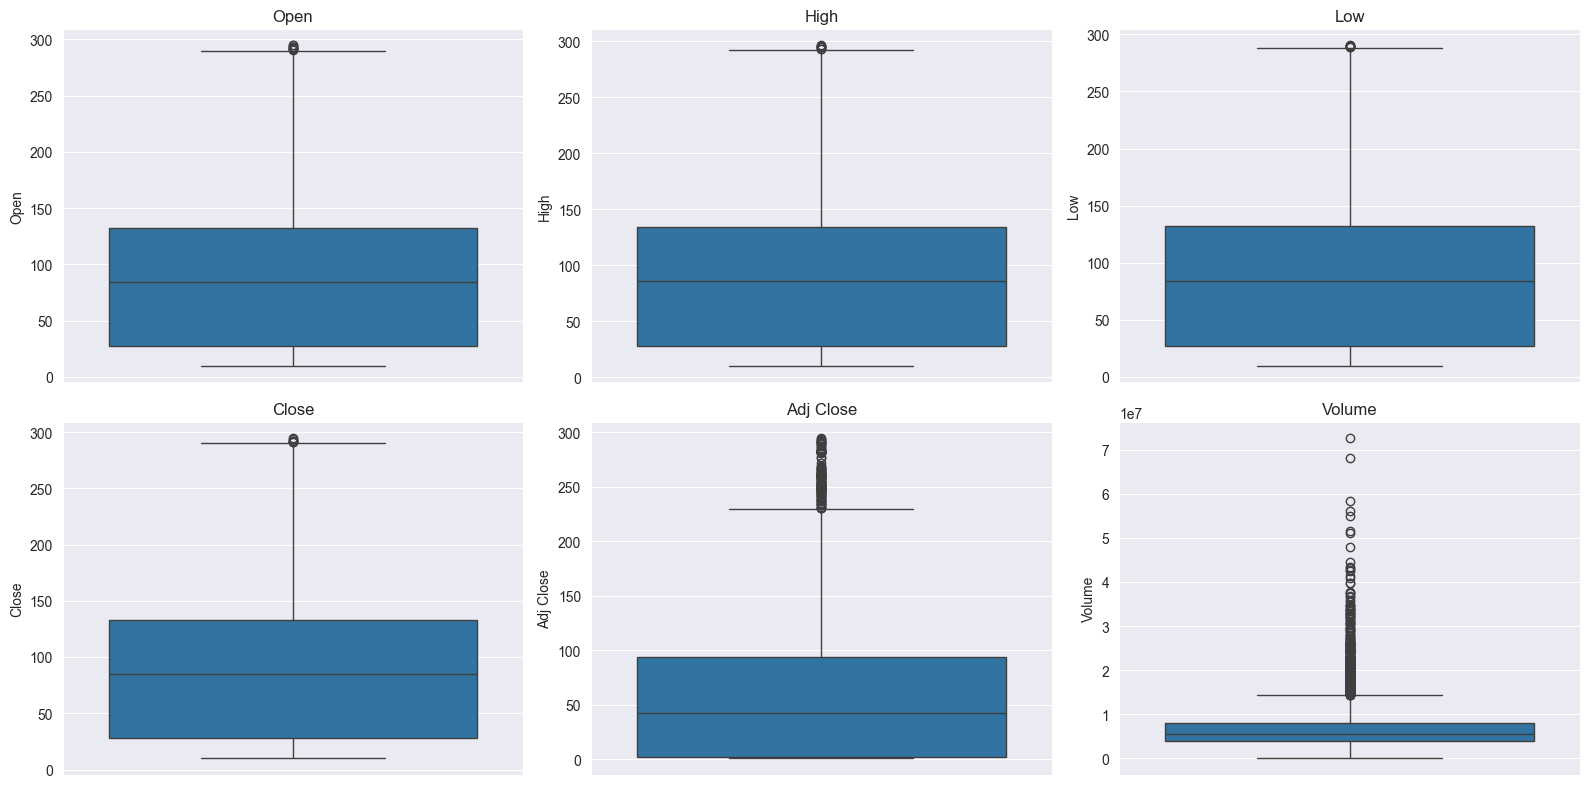

In [71]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
cols_to_plot = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]

for ax, col in zip(axes.flatten(), cols_to_plot):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [ ]:
for col in cols_to_plot:
    print(col, "outliers:", count_outliers_iqr(df[col]))

Open outliers: 9
High outliers: 8
Low outliers: 8
Close outliers: 7
Adj Close outliers: 124
Volume outliers: 560


## Daily returns
Helps see volatility and spot extreme days.

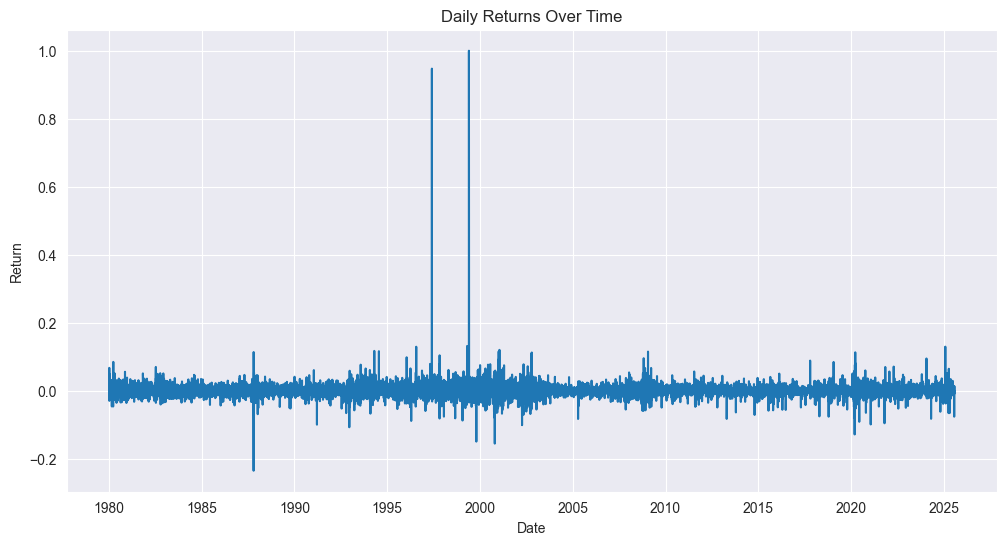

In [73]:
df["daily_return"] = df["Adj Close"].pct_change()

plt.plot(df["Date"], df["daily_return"])
plt.title("Daily Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Return")
plt.show()

In [74]:
df["daily_return"].describe()

count    11487.000000
mean         0.000680
std          0.021145
min         -0.235185
25%         -0.007899
50%          0.000246
75%          0.008651
max          1.000000
Name: daily_return, dtype: float64

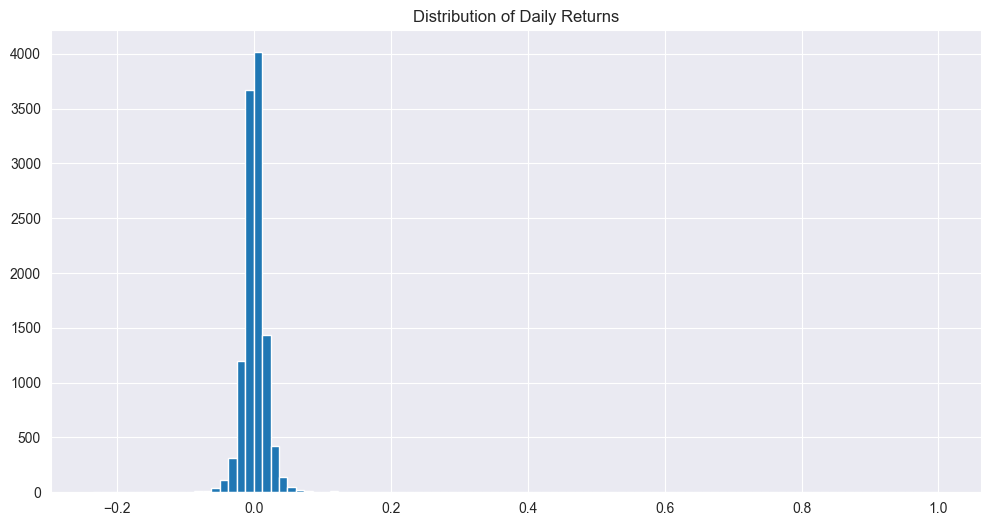

In [75]:
plt.hist(df["daily_return"].dropna(), bins=100)
plt.title("Distribution of Daily Returns")
plt.show()

In [76]:
# biggest single day drops and gains
df.nsmallest(5, "daily_return")[["Date", "daily_return"]]

,Date,daily_return
1971,1987-10-19,-0.235185
5257,2000-10-18,-0.155420
5006,1999-10-21,-0.149533
10135,2020-03-12,-0.128507
3276,1992-12-15,-0.107356


In [77]:
df.nlargest(5, "daily_return")[["Date", "daily_return"]]

,Date,daily_return
4905,1999-05-28,1.000000
4401,1997-05-29,0.947295
4879,1999-04-22,0.131636
11363,2025-01-30,0.129642
4188,1996-07-25,0.129428


## Yearly summary

In [78]:
df["year"] = df["Date"].dt.year
yearly = df.groupby("year")["Adj Close"].agg(["mean", "min", "max"])
yearly.tail(15)

,mean,min,max
year,,,
2011,92.989087,79.276778,106.678720
2012,108.719109,98.234778,117.136669
2013,109.286158,97.744710,120.847468
2014,104.874966,88.167136,113.041069
2015,91.893491,79.254620,102.853265
2016,92.472666,71.626331,105.249784
2017,100.318113,89.772519,114.554637
2018,95.382553,73.035784,109.773625
2019,95.356806,76.661434,105.253168


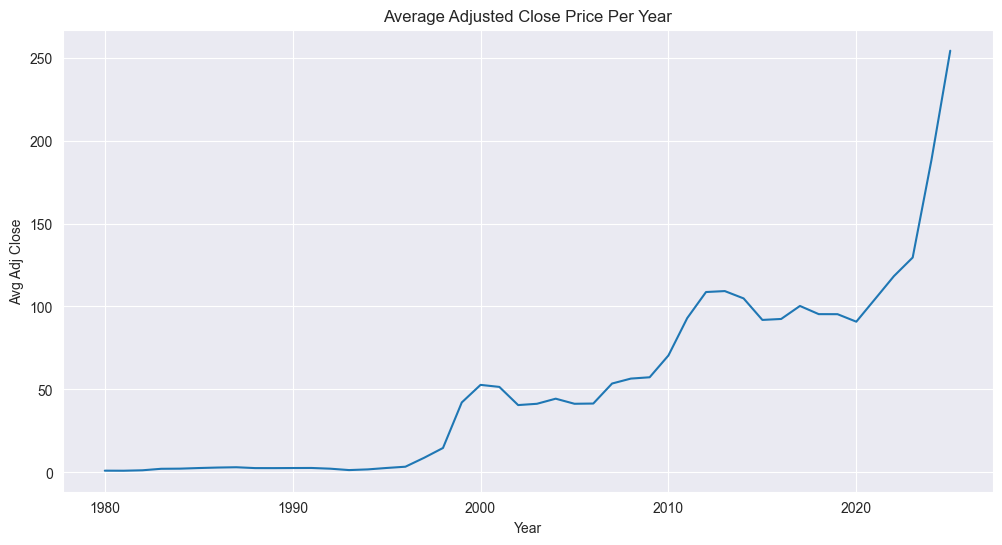

In [79]:
plt.plot(yearly.index, yearly["mean"])
plt.title("Average Adjusted Close Price Per Year")
plt.xlabel("Year")
plt.ylabel("Avg Adj Close")
plt.show()